In [3]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [4]:
# Reinstall datasets and transformers to fix potential conflicts
!pip install --upgrade --force-reinstall datasets transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import EarlyStoppingCallback

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from transformers import set_seed
set_seed(42)


# -----------------------
# A) Load your JSONL file
# -----------------------
# This reads each JSON line as one training example.
data_files = {
    "train": "/content/drive/MyDrive/nlpPro/data3/HebNLI_train_full_and_new.jsonl",
    "validation": "/content/drive/MyDrive/nlpPro/data3/HebNLI_val.full.clean.jsonl",
    "test": "/content/drive/MyDrive/nlpPro/data3/HebNLI_test.full.clean.jsonl"
    }
ds = load_dataset("json", data_files=data_files)


# -----------------------
# B) Label mapping
# -----------------------
label_list = ["entailment", "contradiction", "neutral"]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

def add_label_id(example):
    example["label"] = label2id[example["original_label"]]
    return example

ds = ds.map(add_label_id)

# -----------------------
# C) Tokenizer (heBERT)
# -----------------------
# Tokenizer turns Hebrew text into numbers the model understands.
model_name = "avichr/heBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# -----------------------
# D) Model for 3-class classification - MOVED HERE
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

# Ensure PAD exists (some checkpoints are missing it)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "[PAD]"})

# If tokenizer has more tokens than model embeddings, resize
if len(tokenizer) != model.config.vocab_size:
    model.resize_token_embeddings(len(tokenizer))

print("AFTER FIX -> model vocab_size:", model.config.vocab_size, "tokenizer len:", len(tokenizer))
print("pad token:", tokenizer.pad_token, "pad_id:", tokenizer.pad_token_id)


def tokenize_pair(example):
    return tokenizer(
        example["translation1"],
        example["translation2"],
        truncation=True,
        max_length=256,
    )

ds_tok = ds.map(tokenize_pair, batched=False)
cols = ["input_ids", "attention_mask", "label"]
ds_tok = ds_tok.remove_columns([c for c in ds_tok["train"].column_names if c not in cols])

def find_bad_example(split="train", limit=10000):
    emb_size = model.get_input_embeddings().weight.shape[0]
    ds_split = ds_tok[split]
    n = min(limit, len(ds_split))

    for i in range(n):
        ids = ds_split[i]["input_ids"]
        mx = max(ids)
        mn = min(ids)
        if mn < 0 or mx >= emb_size:
            print("BAD EXAMPLE FOUND!")
            print("split:", split, "index:", i)
            print("min_id:", mn, "max_id:", mx, "emb_size:", emb_size)
            print("translation1:", ds[split][i]["translation1"])
            print("translation2:", ds[split][i]["translation2"])
            print("input_ids:", ids[:80], "...")
            return i

    print(f"No bad examples found in first {n} rows of {split}")
    return None

find_bad_example("train")
find_bad_example("validation")
find_bad_example("test")


# This pads batches nicely (so all examples in a batch have same length).
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# -----------------------
# E) Metrics (what “results” you’ll see)
# -----------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}

# -----------------------
# F) Training settings
# -----------------------
args = TrainingArguments(
    output_dir="HeBert_bert_final_fulltrain",
    learning_rate=3.23654591745491e-05,
    warmup_ratio=0.08906164399134997,
    weight_decay=0.03896128167005955,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    seed=42,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
)


# -----------------------
# G) Trainer (does the training loop)
# -----------------------
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.02)]
)

# -----------------------
# H) Train + Evaluate
# -----------------------
trainer.train()

print("\nFINAL TEST RESULTS:")
test_out = trainer.predict(ds_tok["test"])
test_logits = test_out.predictions
test_labels = test_out.label_ids
test_preds = np.argmax(test_logits, axis=-1)

print(classification_report(test_labels, test_preds, target_names=label_list, digits=4))
print("Confusion matrix (rows=true, cols=pred) label order:", label_list)
print(confusion_matrix(test_labels, test_preds))

# -----------------------
# I) Per-genre results (nice for your report)
# -----------------------
test_genres = ds["test"]["genre"]
print("\nPer-genre macro-F1:")
for g in sorted(set(test_genres)):
    idx = [i for i, gg in enumerate(test_genres) if gg == g]
    g_labels = test_labels[idx]
    g_preds = test_preds[idx]
    g_f1 = f1_score(g_labels, g_preds, average="macro")
    print(f"  {g:12s} n={len(idx):4d} macro_f1={g_f1:.4f}")

# -----------------------
# J) Save the model (required deliverable)
# -----------------------
save_path = "/content/drive/MyDrive/nlpPro/heBERT_nli_full_new_data_early_stopping"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print('saving the modal!')

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/299872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1999 [00:00<?, ? examples/s]

...

No bad examples found in first 10000 rows of train
No bad examples found in first 1999 rows of validation
No bad examples found in first 884 rows of test


/tmp/ipython-input-2618359045.py:149: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.718200,0.686850,0.715358,0.715386
2,0.634900,0.647887,0.733367,0.733428
3,0.506200,0.732321,0.734867,0.734597



FINAL TEST RESULTS:


               precision    recall  f1-score   support

   entailment     0.7754    0.8289    0.8013       304
contradiction     0.7880    0.8111    0.7994       307
      neutral     0.7572    0.6740    0.7132       273

     accuracy                         0.7749       884
    macro avg     0.7735    0.7713    0.7713       884
 weighted avg     0.7741    0.7749    0.7734       884

Confusion matrix (rows=true, cols=pred) label order: ['entailment', 'contradiction', 'neutral']
[[252  20  32]
 [ 31 249  27]
 [ 42  47 184]]

Per-genre macro-F1:
  fiction      n= 223 macro_f1=0.8163
  government   n= 206 macro_f1=0.7888
  letters      n=   7 macro_f1=1.0000
  nineeleven   n=   6 macro_f1=0.6667
  oup          n=   4 macro_f1=1.0000
  slate        n= 215 macro_f1=0.7047
  travel       n= 223 macro_f1=0.7615
saving the modal!


In [4]:
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.special import softmax

probs = softmax(test_logits, axis=1)  # shape: (N, 3)

# One-vs-Rest ROC AUC
auc_macro_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="macro")
auc_weighted_ovr = roc_auc_score(test_labels, probs, multi_class="ovr", average="weighted")

print("ROC-AUC macro (OvR):", auc_macro_ovr)
print("ROC-AUC weighted (OvR):", auc_weighted_ovr)


ROC-AUC macro (OvR): 0.907410410590422
ROC-AUC weighted (OvR): 0.908152817125061


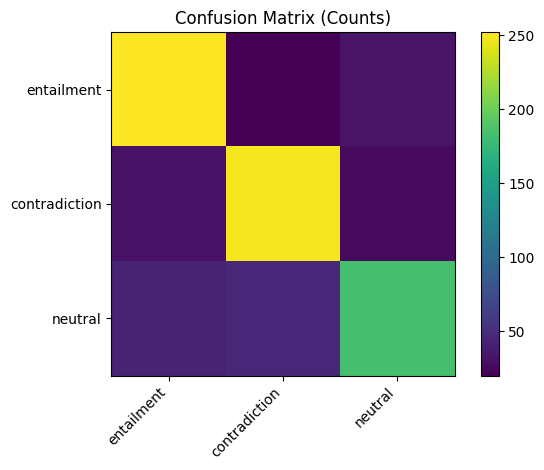

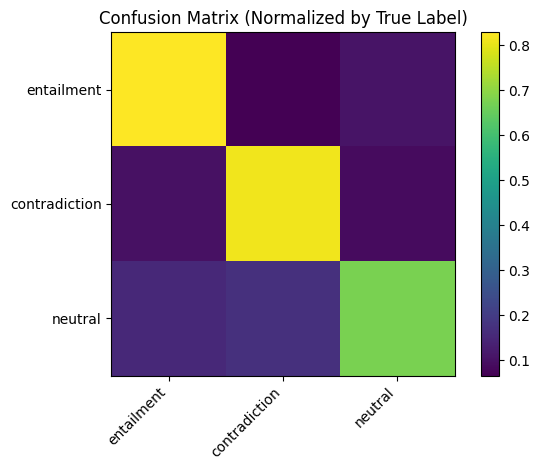

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_preds)

# counts
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Counts)")
plt.xticks(range(len(label_list)), label_list, rotation=45, ha="right")
plt.yticks(range(len(label_list)), label_list)
plt.colorbar()
plt.tight_layout()
plt.show()

# normalized by true class
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure()
plt.imshow(cm_norm)
plt.title("Confusion Matrix (Normalized by True Label)")
plt.xticks(range(len(label_list)), label_list, rotation=45, ha="right")
plt.yticks(range(len(label_list)), label_list)
plt.colorbar()
plt.tight_layout()
plt.show()


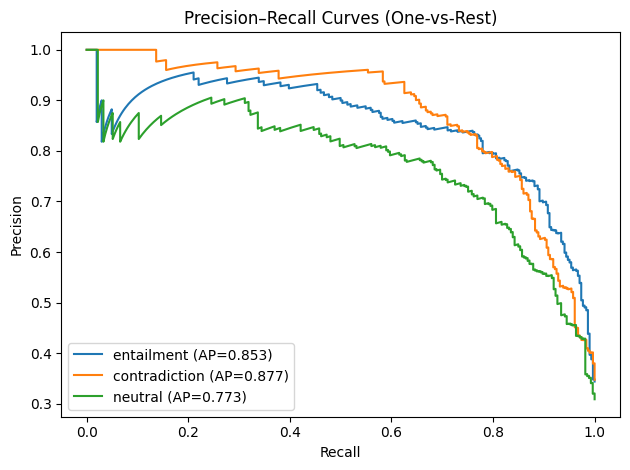

In [6]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_true_bin = label_binarize(test_labels, classes=[0,1,2])  # shape (N,3)

plt.figure()
for i, name in enumerate(label_list):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], probs[:, i])
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

plt.title("Precision–Recall Curves (One-vs-Rest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd

inv_id2label = {0:"entailment", 1:"contradiction", 2:"neutral"}

rows = []
for i in range(len(test_labels)):
    true_id = int(test_labels[i])
    pred_id = int(test_preds[i])
    if true_id != pred_id:
        rows.append({
            "i": i,
            "genre": ds["test"][i]["genre"],
            "t1": ds["test"][i]["translation1"],
            "t2": ds["test"][i]["translation2"],
            "true": inv_id2label[true_id],
            "pred": inv_id2label[pred_id],
            "pred_conf": float(probs[i, pred_id]),
            "true_conf": float(probs[i, true_id]),
            "margin": float(probs[i, pred_id] - probs[i, true_id]),
        })

err_df = pd.DataFrame(rows)
print("Total errors:", len(err_df))
err_df.sort_values("pred_conf", ascending=False).head(10)




Total errors: 199


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
136,578,travel,"באותו הזמן היה בכלא, בשל הסתה למרד, חבר מפלגת ...","ג'ווהרלל נהרו התחנך בבריטניה, אך לא היה אינטלק...",neutral,contradiction,0.989276,0.008291,0.980985
1,19,fiction,"היא שומרת את המכתב הקטלני.""",המכתב הקטלני לא הושלך.,entailment,contradiction,0.989157,0.002434,0.986723
176,785,travel,"המופע במיטבו בימי סוף השבוע אחר הצהריים, ואפשר...","המופע עדיין די טוב בבוקר, אבל לא במיטבו.",neutral,contradiction,0.988815,0.008891,0.979924
64,264,slate,בספר הזיכרונות שלו הוא אומר שביקש מאחות לבדוק ...,האחות לא מצאה דבר כשבדקה אותה.,neutral,contradiction,0.988521,0.009331,0.979190
153,673,slate,המשמעות של מופע כזה היא שהמוזיאון צריך לבחון ה...,המוזיאון לא רצה לבחון מקרוב את תפקידו בעולם הא...,neutral,contradiction,0.988210,0.009606,0.978604
90,391,government,אנחנו עדיין צריכים למצוא את הבדיקה המדויקת ביו...,הבדיקה המדויקת ביותר לשימוש ב- עדיין לא נמצאה.,entailment,contradiction,0.987619,0.002167,0.985452
8,54,fiction,זעקתו של האיש הענק פסקה כאשר כדור עופרת מאקדחו...,האיש שתק כשהכדור חדר לגולגולתו.,entailment,contradiction,0.987601,0.002350,0.985252
116,498,travel,לבראון תומאס יש מחלקת פשתן נהדרת בקומה העליונה.,לבראון תומאס יש מחלקה נהדרת לפשתן.,neutral,entailment,0.983819,0.009945,0.973874
180,794,travel,"בהתחלה זה הביא להקמת ממלכה עצמאית של מיורקה, ת...",ז'אומה השני ירש את ז'אומה השלישי כמנהיג מיורקה.,contradiction,entailment,0.983653,0.007424,0.976229
161,710,travel,התוצאה הייתה ארבעת חדרי רפאל ( ).,התוצאה הייתה 3 חדרי רפאל.,contradiction,entailment,0.983135,0.008478,0.974657


In [8]:
print("\nTop 5 confidently wrong:")
display(err_df.sort_values("pred_conf", ascending=False).head(5))

print("\nTop 5 ambiguous (small margin):")
display(err_df.sort_values("margin", ascending=True).head(5))

print("\nErrors by genre:")
display(err_df["genre"].value_counts())



Top 5 confidently wrong:


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
136,578,travel,"באותו הזמן היה בכלא, בשל הסתה למרד, חבר מפלגת ...","ג'ווהרלל נהרו התחנך בבריטניה, אך לא היה אינטלק...",neutral,contradiction,0.989276,0.008291,0.980985
1,19,fiction,"היא שומרת את המכתב הקטלני.""",המכתב הקטלני לא הושלך.,entailment,contradiction,0.989157,0.002434,0.986723
176,785,travel,"המופע במיטבו בימי סוף השבוע אחר הצהריים, ואפשר...","המופע עדיין די טוב בבוקר, אבל לא במיטבו.",neutral,contradiction,0.988815,0.008891,0.979924
64,264,slate,בספר הזיכרונות שלו הוא אומר שביקש מאחות לבדוק ...,האחות לא מצאה דבר כשבדקה אותה.,neutral,contradiction,0.988521,0.009331,0.979190
153,673,slate,המשמעות של מופע כזה היא שהמוזיאון צריך לבחון ה...,המוזיאון לא רצה לבחון מקרוב את תפקידו בעולם הא...,neutral,contradiction,0.988210,0.009606,0.978604



Top 5 ambiguous (small margin):


,i,genre,t1,t2,true,pred,pred_conf,true_conf,margin
110,470,travel,(הביטוי הפופולרי לקפוץ ממרפסת קיומיזו פירושו ל...,לקפוץ ממרפסת קיומיזו פירושו לעשות משהו נועז וה...,neutral,entailment,0.480173,0.478242,0.001931
55,215,slate,"דוהאם, שמתפרנסת כיום כמעצבת גרפית ומאיירת, מכנ...","היה לה את שם הספר, עוד לפני שהתחילה לכתוב.",neutral,contradiction,0.380616,0.378565,0.002051
20,107,fiction,השאלה מה לעשות עם הדבר האמיתי הדאיגה אותי מאוד.,דאגתי אם הדבר ינשך אותי או לא.,neutral,contradiction,0.409625,0.404732,0.004893
114,488,travel,"במורד תמצאו את מסגד איסה ביי המרשים (1375), ומ...",ישנם מספר כבישים במורד הגבעה שמובילים כולם למסגד.,neutral,contradiction,0.501147,0.489154,0.011992
85,364,government,"כאשר אזרחים עניים נקלעים לצרות פליליות, עומדים...",אזרחים חייבים לשכור עורכי דין פרטיים אם הם רוצ...,contradiction,neutral,0.380978,0.366143,0.014835



Errors by genre:


,count
genre,
slate,62
travel,53
government,43
fiction,39
nineeleven,2


In [33]:
from transformers import pipeline

# 1. טעינת המודל והטוקנייזר מהתיקייה ששמרת ב-Drive
model_path = "/content/drive/MyDrive/nlpPro/heBERT_nli_full_new_data_early_stopping"
nli_predictor = pipeline("text-classification", model=model_path, tokenizer=model_path)

# 2. הגדרת דוגמה (Premise + Hypothesis)
# ב-NLI, אנחנו בדרך כלל מחברים את שני המשפטים עם תו מפריד (ה-Pipeline עושה זאת עבורך)
premise = "אני אוהב לאכול כל היום"
hypothesis = "אני אוהב לאכול רק עכשיו"

# 3. הרצה
result = nli_predictor(f"{premise} [SEP] {hypothesis}")

# הצגת התוצאה
print(f"Prediction: -- {result[0]['label']} --, Confidence: {result[0]['score']:.4f}")

Device set to use cuda:0


Prediction: -- contradiction --, Confidence: 0.5403


In [11]:
# finding fp/fn per label
import numpy as np

labels = ["entailment","contradiction","neutral"]
for i, name in enumerate(labels):
    fp = np.sum((test_preds == i) & (test_labels != i))
    fn = np.sum((test_preds != i) & (test_labels == i))
    tp = np.sum((test_preds == i) & (test_labels == i))
    tn = np.sum((test_preds != i) & (test_labels != i))
    print(f"{name:13s} TP={tp:3d} FP={fp:3d} FN={fn:3d} TN={tn:3d}")


entailment    TP=252 FP= 73 FN= 52 TN=507
contradiction TP=249 FP= 67 FN= 58 TN=510
neutral       TP=184 FP= 59 FN= 89 TN=552


In [12]:
# examples for FP/FN of neutral
target = "neutral"
target_id = labels.index(target)

fp_idx = np.where((test_preds == target_id) & (test_labels != target_id))[0]
fn_idx = np.where((test_preds != target_id) & (test_labels == target_id))[0]

print("FP examples for", target, ":", len(fp_idx))
print("FN examples for", target, ":", len(fn_idx))

# show a few
for i in fp_idx[:5]:
    print("\nTRUE:", labels[test_labels[i]], "| PRED:", labels[test_preds[i]], "| genre:", ds["test"][int(i)]["genre"])
    print("t1:", ds["test"][int(i)]["translation1"])
    print("t2:", ds["test"][int(i)]["translation2"])

FP examples for neutral : 59
FN examples for neutral : 89

TRUE: entailment | PRED: neutral | genre: fiction
t1: מה אתה רואה בעיירה כזאת? שאל ג'ון.
t2: מהם חלק מההיבטים שמושכים אותך אל העיר הזו? שאל ג'ון.

TRUE: entailment | PRED: neutral | genre: fiction
t1: אני חושב שהם חיכו שאמציא משהו.
t2: הם חיכו שאמציא משהו שיעזור.

TRUE: contradiction | PRED: neutral | genre: fiction
t1: לחבוש מגן לאורך הגולגולת שלו; אולי זה בלבל לו את המחשבה קצת."
t2: חבישת המגן ליד גולגולתו באמת חידדה את מחשבתו.

TRUE: entailment | PRED: neutral | genre: fiction
t1: ובפעם המאה, אני אגיד לך שאתה כאן.
t2: אני אומר לך איפה אתה נמצא, כפי שכבר עשיתי פעמים רבות.

TRUE: contradiction | PRED: neutral | genre: fiction
t1: ספר אלקטרוני חינם מ- ://./
t2: הספר הוא בכריכה רכה.


In [13]:
target = "neutral"
target_id = labels.index(target)

pred_neutral_idx = np.where(test_preds == target_id)[0]
avg_conf_pred_neutral = probs[pred_neutral_idx, target_id].mean()
print("Avg confidence when predicting neutral:", avg_conf_pred_neutral)

true_neutral_idx = np.where(test_labels == target_id)[0]
avg_conf_true_neutral = probs[true_neutral_idx, target_id].mean()
print("Avg confidence on TRUE neutral examples:", avg_conf_true_neutral)

fp_idx = np.where((test_preds == target_id) & (test_labels != target_id))[0]
fn_idx = np.where((test_preds != target_id) & (test_labels == target_id))[0]
avg_conf_fp = probs[fp_idx, target_id].mean() if len(fp_idx) else float("nan")
avg_conf_fn = probs[fn_idx, target_id].mean() if len(fn_idx) else float("nan")
print("Avg P(neutral) for FP neutral:", avg_conf_fp)
print("Avg P(neutral) for FN neutral:", avg_conf_fn)

avg_wrong_conf_fn = probs[fn_idx, test_preds[fn_idx]].mean() if len(fn_idx) else float("nan")
print("Avg confidence in the WRONG predicted label (on FN neutral):", avg_wrong_conf_fn)



Avg confidence when predicting neutral: 0.83879334
Avg confidence on TRUE neutral examples: 0.6399637
Avg P(neutral) for FP neutral: 0.75215834
Avg P(neutral) for FN neutral: 0.17146783
Avg confidence in the WRONG predicted label (on FN neutral): 0.77183604


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

we have 2 way to evaluate


1.   to check by confidence
2.   to check by labels

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

In [14]:
# option 1
import numpy as np
import pandas as pd
from scipy.special import softmax

label_list = ["entailment", "contradiction", "neutral"]
id2label = {i:l for i,l in enumerate(label_list)}

# test_logits, test_labels, test_preds must already exist
probs = softmax(test_logits, axis=1)  # shape (N, 3)


In [15]:
# option 1 exapmls
# Top 15 confident wrong predictions
top_conf_errors = err_df.sort_values("pred_conf", ascending=False).head(15)

for _, r in top_conf_errors.iterrows():
    print("\n" + "="*80)
    print(f"Index {r['i']} | genre={r['genre']}")
    print(f"TRUE={r['true']} | PRED={r['pred']} | pred_conf={r['pred_conf']:.3f} | true_conf={r['true_conf']:.3f}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])



Index 578 | genre=travel
TRUE=neutral | PRED=contradiction | pred_conf=0.989 | true_conf=0.008
t1: באותו הזמן היה בכלא, בשל הסתה למרד, חבר מפלגת הקונגרס ג'ווהרלל נהרו, שהתחנך בבריטניה אך היה גם אינטלקטואל ברהמני, כפי שמרמז תואר הכבוד שלו - פאנדיט.
t2: ג'ווהרלל נהרו התחנך בבריטניה, אך לא היה אינטלקטואל ברמהין.

Index 19 | genre=fiction
TRUE=entailment | PRED=contradiction | pred_conf=0.989 | true_conf=0.002
t1: היא שומרת את המכתב הקטלני."
t2: המכתב הקטלני לא הושלך.

Index 785 | genre=travel
TRUE=neutral | PRED=contradiction | pred_conf=0.989 | true_conf=0.009
t1: המופע במיטבו בימי סוף השבוע אחר הצהריים, ואפשר לראות שם הכול, החל מנערי חוף על חד אופן ועד רוקרים מחליקים על רולר בליידס.
t2: המופע עדיין די טוב בבוקר, אבל לא במיטבו.

Index 264 | genre=slate
TRUE=neutral | PRED=contradiction | pred_conf=0.989 | true_conf=0.009
t1: בספר הזיכרונות שלו הוא אומר שביקש מאחות לבדוק אותה.
t2: האחות לא מצאה דבר כשבדקה אותה.

Index 673 | genre=slate
TRUE=neutral | PRED=contradiction | pred_conf=0.988 

In [16]:
# option 1 to check if negative like no in one t1 and not the other is the coes of the the high conf
# Many high-confidence errors contain negation in only one sentence, suggesting the model overreacts to negation cues ? no just 6
import re

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")

def has_neg(s):
    return bool(NEG_RE.search(str(s)))

def negation_flip(t1, t2):
    return has_neg(t1) ^ has_neg(t2)  # True if only one has negation

top = err_df.sort_values("pred_conf", ascending=False).head(30).copy()
top["neg_flip"] = top.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

print("How many of top 30 errors have negation flip:", top["neg_flip"].sum())
top[top["neg_flip"]][["true","pred","pred_conf","t1","t2"]].head(5)



How many of top 30 errors have negation flip: 9


,true,pred,pred_conf,t1,t2
136,neutral,contradiction,0.989276,"באותו הזמן היה בכלא, בשל הסתה למרד, חבר מפלגת ...","ג'ווהרלל נהרו התחנך בבריטניה, אך לא היה אינטלק..."
1,entailment,contradiction,0.989157,"היא שומרת את המכתב הקטלני.""",המכתב הקטלני לא הושלך.
176,neutral,contradiction,0.988815,"המופע במיטבו בימי סוף השבוע אחר הצהריים, ואפשר...","המופע עדיין די טוב בבוקר, אבל לא במיטבו."
64,neutral,contradiction,0.988521,בספר הזיכרונות שלו הוא אומר שביקש מאחות לבדוק ...,האחות לא מצאה דבר כשבדקה אותה.
153,neutral,contradiction,0.988210,המשמעות של מופע כזה היא שהמוזיאון צריך לבחון ה...,המוזיאון לא רצה לבחון מקרוב את תפקידו בעולם הא...


In [17]:
# option 1 to check if sentences include dates, the model may ignore them and this is the coes of the the high conf
# Many high-confidence errors contain negation in only one sentence, suggesting the model overreacts to negation cues ? no just 0
import re

TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|חודש|שנה|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")

def has_neg(s):
    return bool(TEMP_RE.search(str(s)))

def negation_flip(t1, t2):
    return has_neg(t1) ^ has_neg(t2)  # True if only one has negation

top = err_df.sort_values("pred_conf", ascending=False).head(30).copy()
top["neg_flip"] = top.apply(lambda r: negation_flip(r["t1"], r["t2"]), axis=1)

print("How many of top 30 errors have negation flip:", top["neg_flip"].sum())
top[top["neg_flip"]][["true","pred","pred_conf","t1","t2"]].head(5)


How many of top 30 errors have negation flip: 2


,true,pred,pred_conf,t1,t2
176,neutral,contradiction,0.988815,"המופע במיטבו בימי סוף השבוע אחר הצהריים, ואפשר...","המופע עדיין די טוב בבוקר, אבל לא במיטבו."
42,contradiction,neutral,0.972249,זה היה נותן לשני הצדדים הזדמנות ללמוד זה על זה.,מאמצים לגשר על הפער רק יובילו לעוינות רבה יותר...


In [18]:
# option 1 to check if sentences include numbers, the model may ignore them and this is the coes of the the high conf
# just 7

NUM_RE = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")

def has_number(s):
    return bool(NUM_RE.search(str(s)))

top["has_num"] = top.apply(lambda r: has_number(r["t1"]) or has_number(r["t2"]), axis=1)
print("How many of top 30 errors have numbers:", top["has_num"].sum())
top[top["has_num"]][["true","pred","pred_conf","t1","t2"]].head(5)



How many of top 30 errors have numbers: 4


,true,pred,pred_conf,t1,t2
161,contradiction,entailment,0.983135,התוצאה הייתה ארבעת חדרי רפאל ( ).,התוצאה הייתה 3 חדרי רפאל.
166,contradiction,neutral,0.982362,"הוא שכר חדר, וגם אני שכרתי אחד.","הוא שכר חדר, אבל לא היה לי מספיק כסף בשביל לשכ..."
142,contradiction,neutral,0.982343,"זה היה דומה למן מגן עדן - אלפי דולרים שירדו, ל...",חוק שהוצע לאחרונה על ידי הקונגרס הביא לעיקול א...
50,neutral,entailment,0.969810,"הקטנה מבין חברות הטבק הגדולות, קבוצת ליגט, הסכ...",אלסקה הייתה אחת המדינות שתבעו השבת כספים שהוצא...


In [19]:
# option 1
# In several cases the model predicts entailment even though sentence 2 adds details not stated in sentence 1.
# This suggests the model relies on common-sense assumptions rather than strict logical entailment.
# so we check if

guess_df = err_df[(err_df["true"]=="neutral") & (err_df["pred"]=="entailment")].copy()
guess_df = guess_df.sort_values("pred_conf", ascending=False).head(15)

print(f'amount of gussing: {len(guess_df)}')
for _, r in guess_df.iterrows():
    print("\n" + "="*70)
    print(f"TRUE={r['true']} PRED={r['pred']} conf={r['pred_conf']:.3f}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


amount of gussing: 15

TRUE=neutral PRED=entailment conf=0.984
t1: לבראון תומאס יש מחלקת פשתן נהדרת בקומה העליונה.
t2: לבראון תומאס יש מחלקה נהדרת לפשתן.

TRUE=neutral PRED=entailment conf=0.980
t1: בסדר, דוגמה גרועה.
t2: זו דוגמה רעה.

TRUE=neutral PRED=entailment conf=0.980
t1: כמו כן, לא זוהו נקודות מוסכמות של התחלה או סיום לסקר התיכון כמרכיב בתהליך רכישת המתקנים.
t2: לא זוהתה בבניית המתקן נקודת התחלה או סיום מוסכמת.

TRUE=neutral PRED=entailment conf=0.970
t1: בגרסה החדשה, רייך דבק בתמליל ומצטט במדויק את סקסטון מדבר בהרחבה על לימודים ו״הפיצה של הסנדק״.
t2: הגרסה של רייך מדויקת.

TRUE=neutral PRED=entailment conf=0.970
t1: הקטנה מבין חברות הטבק הגדולות, קבוצת ליגט, הסכימה להסדר עם היועצים המשפטיים של 22 מדינות שתבעו החזרת כספים שהוצאו על שירותי בריאות למעשנים.
t2: אלסקה הייתה אחת המדינות שתבעו השבת כספים שהוצאו על טיפול רפואי למעשנים.

TRUE=neutral PRED=entailment conf=0.959
t1: עקוב אחר לוח הקנו המואר מעליך כדי לראות אם עולים לך מספיק מספרים כדי שתוכל לזכות.
t2: לוח הקנו נדלק ומראה

In [20]:
# option 1
# Maybe the label is wrong
# 2 ways to ckeck this:
# number 1 if confidence > 0.95
noise_candidates = err_df[err_df["pred_conf"] > 0.95].sort_values("pred_conf", ascending=False).head(20)
print(f'amount of noise candidates: {len(noise_candidates)}')

for _, r in noise_candidates.iterrows():
    print("\n" + "="*70)
    print(f"TRUE={r['true']} PRED={r['pred']} conf={r['pred_conf']:.3f} genre={r['genre']}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


amount of noise candidates: 20

TRUE=neutral PRED=contradiction conf=0.989 genre=travel
t1: באותו הזמן היה בכלא, בשל הסתה למרד, חבר מפלגת הקונגרס ג'ווהרלל נהרו, שהתחנך בבריטניה אך היה גם אינטלקטואל ברהמני, כפי שמרמז תואר הכבוד שלו - פאנדיט.
t2: ג'ווהרלל נהרו התחנך בבריטניה, אך לא היה אינטלקטואל ברמהין.

TRUE=entailment PRED=contradiction conf=0.989 genre=fiction
t1: היא שומרת את המכתב הקטלני."
t2: המכתב הקטלני לא הושלך.

TRUE=neutral PRED=contradiction conf=0.989 genre=travel
t1: המופע במיטבו בימי סוף השבוע אחר הצהריים, ואפשר לראות שם הכול, החל מנערי חוף על חד אופן ועד רוקרים מחליקים על רולר בליידס.
t2: המופע עדיין די טוב בבוקר, אבל לא במיטבו.

TRUE=neutral PRED=contradiction conf=0.989 genre=slate
t1: בספר הזיכרונות שלו הוא אומר שביקש מאחות לבדוק אותה.
t2: האחות לא מצאה דבר כשבדקה אותה.

TRUE=neutral PRED=contradiction conf=0.988 genre=slate
t1: המשמעות של מופע כזה היא שהמוזיאון צריך לבחון היטב את תפקידו - השנוי במחלוקת לעיתים - בעולם האמנות.
t2: המוזיאון לא רצה לבחון מקרוב את תפקידו 

In [21]:
# option 1
# the second way to check if the labes are wrong is by checkig if there is a overlap
# so the PRED label  should be 'entailment' but we get neutral / contradictions

def overlap_ratio(t1, t2):
    A = set(re.findall(r"[\u0590-\u05FF]{2,}", str(t1)))
    B = set(re.findall(r"[\u0590-\u05FF]{2,}", str(t2)))
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

err_df["overlap"] = err_df.apply(lambda r: overlap_ratio(r["t1"], r["t2"]), axis=1)

suspect_paraphrase = err_df[err_df["overlap"] > 0.45].sort_values("pred_conf", ascending=False).head(15)
print(f'amount of suspect paraphrase: {len(suspect_paraphrase)}')
suspect_paraphrase[["true","pred","pred_conf","overlap","t1","t2"]].head(5)


amount of suspect paraphrase: 3


,true,pred,pred_conf,overlap,t1,t2
90,entailment,contradiction,0.987619,0.454545,אנחנו עדיין צריכים למצוא את הבדיקה המדויקת ביו...,הבדיקה המדויקת ביותר לשימוש ב- עדיין לא נמצאה.
161,contradiction,entailment,0.983135,0.800000,התוצאה הייתה ארבעת חדרי רפאל ( ).,התוצאה הייתה 3 חדרי רפאל.
134,neutral,entailment,0.957151,0.500000,האדם הראשון שנוגע בקרקע עם חלק בגוף מלבד הרגלי...,האדם הראשון שנוגע עם הידיים בקרקע מפסיד.


In [22]:
# option 2
# to check which confusion happens the most:
import pandas as pd

# err_df must have columns: true, pred, pred_conf, genre, t1, t2
mistake_counts = (
    err_df.groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(mistake_counts.to_string(index=False))


         true          pred  count
      neutral contradiction     47
      neutral    entailment     42
   entailment       neutral     32
contradiction    entailment     31
contradiction       neutral     27
   entailment contradiction     20


In [23]:
# option 2
# to inspect this type of error because its the most times th model got confused

true_label = "entailment"
pred_label = "neutral"

subset = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)].copy()

print("How many mistakes of this type:", len(subset))
print("Average confidence for this wrong prediction:", subset["pred_conf"].mean())

# show the top confident wrong ones (best for analysis)
subset = subset.sort_values("pred_conf", ascending=False).head(10)

for _, r in subset.iterrows():
    print("\n" + "="*80)
    print(f"TRUE={r['true']} | PRED={r['pred']} | conf={r['pred_conf']:.3f} | genre={r['genre']}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


How many mistakes of this type: 32
Average confidence for this wrong prediction: 0.751532843336463

TRUE=entailment | PRED=neutral | conf=0.983 | genre=government
t1: הנחיה רחבה זו נועדה לספק את דרישות הדיווח הבסיסיות תוך מתן גמישות מירבית לכל ישות בתחומים אלה לקביעת מה מהווים פריטי האחריות האישיים עבור ישות זו, אילו עלויות מיוחסות ישירות לפריט האחריות, וכיצד לדווח בצורה הטובה ביותר על פריטים לשימושים מרובים כדי שהמשתמשים יקבלו את התמונה הטובה ביותר של המידע הפיננסי וביצועי הישות.
t2: ההנחיות הרחבות נועדו לתת תקני דיווח בסיסיים תוך מתן גמישות לכל סוכנות בקבלת החלטות.

TRUE=entailment | PRED=neutral | conf=0.982 | genre=government
t1: תקני חשבונאות לעלות ניהולית
t2: תקני עלויות ניהוליות עבור רואי חשבון

TRUE=entailment | PRED=neutral | conf=0.982 | genre=travel
t1: מחרוזות של דגלי תפילה נמתחות מצריח הפעמון, וסביב הבסיס יש מאות גלגלי תפילה קטנים.
t2: דת היא דבר חשוב כאן.

TRUE=entailment | PRED=neutral | conf=0.980 | genre=slate
t1: זאת מחויבות לחינוך כללי - סדרה של קורסים שמטרתה לפתח חש

In [24]:
# option 2
# to inspect this type of error becaues its the scond most time the model got confused

true_label = "contradiction"
pred_label = "neutral"

subset = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)].copy()

print("How many mistakes of this type:", len(subset))
print("Average confidence for this wrong prediction:", subset["pred_conf"].mean())

# show the top confident wrong ones (best for analysis)
subset = subset.sort_values("pred_conf", ascending=False).head(10)

for _, r in subset.iterrows():
    print("\n" + "="*80)
    print(f"TRUE={r['true']} | PRED={r['pred']} | conf={r['pred_conf']:.3f} | genre={r['genre']}")
    print("t1:", r["t1"])
    print("t2:", r["t2"])


How many mistakes of this type: 27
Average confidence for this wrong prediction: 0.7528995805316501

TRUE=contradiction | PRED=neutral | conf=0.983 | genre=fiction
t1: ספר אלקטרוני חינם מ- ://./
t2: הספר הוא בכריכה רכה.

TRUE=contradiction | PRED=neutral | conf=0.983 | genre=government
t1: זה מעביר את האחריות לבצע את ההתערבות לידי יחידים שכבר מחויבים לספק את השירות ומונע תלות ברופאים שסביר להניח שלא ירכשו מחויבות כזו עד שיתרחשו שינויים משמעותיים בגישה.
t2: רופאים לעתים קרובות אוהבים לבצע התערבויות כי הם לא חושבים שזה באמת עובד.

TRUE=contradiction | PRED=neutral | conf=0.982 | genre=fiction
t1: הוא שכר חדר, וגם אני שכרתי אחד.
t2: הוא שכר חדר, אבל לא היה לי מספיק כסף בשביל לשכור אחד בעצמי.

TRUE=contradiction | PRED=neutral | conf=0.982 | genre=government
t1: זה היה דומה למן מגן עדן - אלפי דולרים שירדו, לעתים קרובות באופן בלתי צפוי, לידיהם של חצי מיליון תושבי קנטאקי ואינדיאנה החודש.
t2: חוק שהוצע לאחרונה על ידי הקונגרס הביא לעיקול אלפי דולרים מתושבי קנטקי.

TRUE=contradiction | PRED=neu

In [25]:
# option 2
# Now we ask: why does neutral become contradiction?
# Common reasons: negation, strong words, numbers, time, etc.

import re

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")
NUM_RE = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")
TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|חודש|שנה|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")

def tags_for_pair(t1, t2):
    tags = []
    t1 = str(t1); t2 = str(t2)

    # negation in exactly one sentence
    if bool(NEG_RE.search(t1)) ^ bool(NEG_RE.search(t2)):
        tags.append("negation_flip")

    if NUM_RE.search(t1) or NUM_RE.search(t2):
        tags.append("numbers")

    if TEMP_RE.search(t1) or TEMP_RE.search(t2):
        tags.append("time")

    return tags

subset2 = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)].copy()
subset2["tags"] = subset2.apply(lambda r: tags_for_pair(r["t1"], r["t2"]), axis=1)

print("Tag counts inside this mistake type:")
print(subset2.explode("tags")["tags"].value_counts())


Tag counts inside this mistake type:
tags
negation_flip    8
numbers          6
time             1
Name: count, dtype: int64


In [26]:
import re
import pandas as pd
import numpy as np

# err_df should already contain: t1,t2,true,pred,genre,pred_conf,margin
# If not, build it as we did earlier.

NEG_RE = re.compile(r"\b(לא|אין|בלי|אף|מעולם)\b")
TEMP_RE = re.compile(r"\b(אתמול|מחר|היום|השבוע|שנה|שנת|חודש|יום|לילה|בוקר|ערב|שני|שלישי|רביעי|חמישי|שישי|שבת|סוף\s*השבוע)\b")
NUM_RE  = re.compile(r"\b(\d+|אחד|אחת|שניים|שתיים|שלושה|שלוש|ארבע|חמש|שש|שבע|שמונה|תשע|עשר|מאה|אלף|מיליון|אחוז)\b")
PRON_RE = re.compile(r"\b(הוא|היא|הם|הן|אותו|אותה|להם|להן|שלו|שלה|שלהם|שלהן)\b")

def tokenize_set(s):
    # Hebrew-only “word” tokens
    return set(re.findall(r"[\u0590-\u05FF]{2,}", s))

def jaccard(a, b):
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def detect_patterns(t1, t2, pred_conf=None, margin=None):
    tags = []

    # Negation flip: negation present in exactly one of the sentences
    n1 = bool(NEG_RE.search(t1))
    n2 = bool(NEG_RE.search(t2))
    if n1 ^ n2:
        tags.append("Negation flip")

    # Temporal
    if TEMP_RE.search(t1) or TEMP_RE.search(t2):
        tags.append("Temporal reasoning")

    # Numbers / quantifiers
    if NUM_RE.search(t1) or NUM_RE.search(t2):
        tags.append("Quantifiers / numbers")

    # Coreference / pronouns
    if PRON_RE.search(t1) or PRON_RE.search(t2):
        tags.append("Coreference / pronouns")

    # Lexical overlap trap: lots of shared words (tends to confuse neutral vs entailment)
    A = tokenize_set(t1)
    B = tokenize_set(t2)
    overlap = jaccard(A, B)
    if overlap >= 0.35:   # tune threshold if needed
        tags.append("Lexical overlap trap")

    # Ambiguity: model not confident (or small margin)
    if pred_conf is not None and pred_conf < 0.45:
        tags.append("Ambiguity")
    if margin is not None and abs(margin) < 0.10:
        if "Ambiguity" not in tags:
            tags.append("Ambiguity")

    return tags

# Apply to err_df
err_df = err_df.copy()
err_df["tags"] = err_df.apply(
    lambda r: detect_patterns(r["t1"], r["t2"], r.get("pred_conf"), r.get("margin")),
    axis=1
)

# Explode into one tag per row for analysis
exploded = err_df.explode("tags")
tag_counts = exploded["tags"].value_counts(dropna=True)
print(tag_counts)


tags
Coreference / pronouns    88
Negation flip             40
Quantifiers / numbers     39
Ambiguity                 22
Lexical overlap trap      14
Temporal reasoning         9
Name: count, dtype: int64


In [28]:
top_conf = err_df.sort_values("pred_conf", ascending=False).head(30)
top_conf[["genre","true","pred","pred_conf","margin"]].head(10)


,genre,true,pred,pred_conf,margin
136,travel,neutral,contradiction,0.989276,0.980985
1,fiction,entailment,contradiction,0.989157,0.986723
176,travel,neutral,contradiction,0.988815,0.979924
64,slate,neutral,contradiction,0.988521,0.979190
153,slate,neutral,contradiction,0.988210,0.978604
90,government,entailment,contradiction,0.987619,0.985452
8,fiction,entailment,contradiction,0.987601,0.985252
116,travel,neutral,entailment,0.983819,0.973874
180,travel,contradiction,entailment,0.983653,0.976229
161,travel,contradiction,entailment,0.983135,0.974657


In [29]:
top_conf_exploded = top_conf.explode("tags")
print(top_conf_exploded["tags"].value_counts())


tags
Coreference / pronouns    10
Negation flip              9
Lexical overlap trap       5
Quantifiers / numbers      4
Temporal reasoning         2
Name: count, dtype: int64


In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, test_preds)
print("Confusion Matrix:")
print(cm)

mistake_counts = (
    err_df.groupby(["true", "pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nMistake Counts (True vs. Predicted):")
print(mistake_counts.to_string(index=False))

Confusion Matrix:
[[252  20  32]
 [ 31 249  27]
 [ 42  47 184]]

Mistake Counts (True vs. Predicted):
         true          pred  count
      neutral contradiction     47
      neutral    entailment     42
   entailment       neutral     32
contradiction    entailment     31
contradiction       neutral     27
   entailment contradiction     20


In [31]:
def slice_errors(true_label, pred_label):
    sub = err_df[(err_df["true"] == true_label) & (err_df["pred"] == pred_label)]
    return sub.sort_values("pred_conf", ascending=False)

sub = slice_errors("neutral","contradiction")
print("count:", len(sub))
sub.head(5)[["genre","pred_conf","t1","t2"]]


count: 47


,genre,pred_conf,t1,t2
136,travel,0.989276,"באותו הזמן היה בכלא, בשל הסתה למרד, חבר מפלגת ...","ג'ווהרלל נהרו התחנך בבריטניה, אך לא היה אינטלק..."
176,travel,0.988815,"המופע במיטבו בימי סוף השבוע אחר הצהריים, ואפשר...","המופע עדיין די טוב בבוקר, אבל לא במיטבו."
64,slate,0.988521,בספר הזיכרונות שלו הוא אומר שביקש מאחות לבדוק ...,האחות לא מצאה דבר כשבדקה אותה.
153,slate,0.988210,המשמעות של מופע כזה היא שהמוזיאון צריך לבחון ה...,המוזיאון לא רצה לבחון מקרוב את תפקידו בעולם הא...
9,fiction,0.974947,הסטיקס שאגו פנימה.,הם פיגרו בלוח הזמנים.


In [32]:
sub_exploded = sub.explode("tags")
print(sub_exploded["tags"].value_counts())


tags
Coreference / pronouns    26
Negation flip             19
Quantifiers / numbers     10
Ambiguity                  5
Temporal reasoning         3
Lexical overlap trap       1
Name: count, dtype: int64


In [34]:
from transformers import pipeline

# 1. טעינת המודל והטוקנייזר מהתיקייה ששמרת ב-Drive
model_path = "/content/drive/MyDrive/nlpPro/heBERT_nli_full_new_data_early_stopping"
nli_predictor = pipeline("text-classification", model=model_path, tokenizer=model_path)

# 2. הגדרת דוגמה (Premise + Hypothesis)
# ב-NLI, אנחנו בדרך כלל מחברים את שני המשפטים עם תו מפריד (ה-Pipeline עושה זאת עבורך)
premise = "אני אוהב לאכול כל היום"
hypothesis = "אני אוהב לאכול רק עכשיו"

# 3. הרצה
result = nli_predictor(f"{premise} [SEP] {hypothesis}")

# הצגת התוצאה
print(f"Prediction: -- {result[0]['label']} --, Confidence: {result[0]['score']:.4f}")

Device set to use cuda:0


Prediction: -- contradiction --, Confidence: 0.5403


In [36]:
from transformers import pipeline

# 1. טעינת המודל והטוקנייזר מהתיקייה ששמרת ב-Drive
model_path = "/content/drive/MyDrive/nlpPro/alephbert_nli_full_best_early_stopping"
nli_predictor = pipeline("text-classification", model=model_path, tokenizer=model_path)

# 2. הגדרת דוגמה (Premise + Hypothesis)
# ב-NLI, אנחנו בדרך כלל מחברים את שני המשפטים עם תו מפריד (ה-Pipeline עושה זאת עבורך)
premise = "אני אוהב לאכול כל היום"
hypothesis = "אני אוהב לאכול רק עכשיו"

# 3. הרצה
result = nli_predictor(f"{premise} [SEP] {hypothesis}")

# הצגת התוצאה
print(f"Prediction: -- {result[0]['label']} --, Confidence: {result[0]['score']:.4f}")

Device set to use cuda:0


Prediction: -- contradiction --, Confidence: 0.9871


In [2]:
from transformers import pipeline
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# ---------- 1) Load pipelines ----------
path_aleph = "/content/drive/MyDrive/nlpPro/alephbert_nli_full_best_early_stopping"
path_hebert = "/content/drive/MyDrive/nlpPro/heBERT_nli_full_new_data_early_stopping"

pipe_aleph = pipeline("text-classification", model=path_aleph, tokenizer=path_aleph, return_all_scores=True)
pipe_hebert = pipeline("text-classification", model=path_hebert, tokenizer=path_hebert, return_all_scores=True)

# ---------- 2) One example ensemble (returns label + confidence + full scores) ----------
def ensemble_predict_with_conf(premise, hypothesis):
    input_text = f"{premise} [SEP] {hypothesis}"

    res_aleph = pipe_aleph(input_text)[0]   # list of dicts: [{'label':..., 'score':...}, ...]
    res_hebert = pipe_hebert(input_text)[0]

    # ensure same label order
    labels = [s["label"] for s in res_aleph]
    scores_aleph = np.array([s["score"] for s in res_aleph], dtype=float)
    scores_hebert = np.array([s["score"] for s in res_hebert], dtype=float)

    final_scores = (scores_aleph + scores_hebert) / 2.0
    best_idx = int(np.argmax(final_scores))

    return labels[best_idx], float(final_scores[best_idx]), dict(zip(labels, final_scores))

# ---------- 3) Load test set ----------
test_path = "/content/drive/MyDrive/nlpPro/data3/HebNLI_test.full.clean.jsonl"
ds_test = load_dataset("json", data_files={"test": test_path})["test"]

# (אם אצלך העמודות הן "translation1"/"translation2" תשתמש בהן. אחרת "sentence1"/"sentence2")
TEXT1_COL = "translation1" if "translation1" in ds_test.column_names else "sentence1"
TEXT2_COL = "translation2" if "translation2" in ds_test.column_names else "sentence2"

# label column could be "original_label" or "label"
LABEL_COL = "original_label" if "original_label" in ds_test.column_names else "label"

# If labels are strings like "entailment"/"contradiction"/"neutral" -> ok.
# If labels are ints -> map them:
label_list = ["entailment", "contradiction", "neutral"]
if isinstance(ds_test[0][LABEL_COL], (int, np.integer)):
    id2label = {i: l for i, l in enumerate(label_list)}
    y_true = [id2label[x] for x in ds_test[LABEL_COL]]
else:
    y_true = list(ds_test[LABEL_COL])

# ---------- 4) Run over test ----------
preds = []
confs = []
scores_dicts = []

for ex in ds_test:
    premise = ex[TEXT1_COL]
    hypothesis = ex[TEXT2_COL]
    pred, conf, scores = ensemble_predict_with_conf(premise, hypothesis)
    preds.append(pred)
    confs.append(conf)
    scores_dicts.append(scores)

# ---------- 5) Metrics ----------
acc = accuracy_score(y_true, preds)
macro_f1 = f1_score(y_true, preds, average="macro")
cm = confusion_matrix(y_true, preds, labels=label_list)

print("Accuracy:", acc)
print("Macro-F1:", macro_f1)
print("\nClassification report:\n", classification_report(y_true, preds, labels=label_list))
print("\nConfusion matrix (rows=true, cols=pred):\n", cm)

# ---------- 6) Save a results table (optional) ----------
df = pd.DataFrame({
    "premise": ds_test[TEXT1_COL],
    "hypothesis": ds_test[TEXT2_COL],
    "true": y_true,
    "pred": preds,
    "ensemble_conf": confs,
})

# add per-label ensemble scores as columns (optional)
for lbl in label_list:
    df[f"ens_{lbl}"] = [d.get(lbl, np.nan) for d in scores_dicts]

out_csv = "/content/drive/MyDrive/nlpPro/ensemble_test_predictions.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# ---------- 7) (Optional) Error analysis: top confident mistakes ----------
mistakes = df[df["true"] != df["pred"]].sort_values("ensemble_conf", ascending=False)
display(mistakes.head(20))


HFValidationError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/drive/MyDrive/nlpPro/alephbert_nli_full_best_early_stopping'. Use `repo_type` argument if needed.